# TensorFlow Playground: Hands-on Guide

[TensorFlow Playground](https://playground.tensorflow.org/) is a web app that lets you configure a small neural network and **see it learn in real time** on synthetic 2D datasets.

This notebook walks through a series of experiments you can run in the Playground, each illustrating a key concept. For each experiment we also show the equivalent PyTorch code so you can connect the visual intuition with real implementation.

> **How to use this notebook:** open [playground.tensorflow.org](https://playground.tensorflow.org/) in a separate tab and follow the experiment instructions. Then run the PyTorch cells to see the same behavior in code.

## Playground controls

| Control | What it does |
|---------|-------------|
| **Dataset** (left panel) | Choose a pattern: two clusters, circle, XOR, spiral |
| **Features** | Toggle input transformations: $x_1^2$, $x_2^2$, $x_1 \times x_2$, sin, cos |
| **Hidden layers** | Add/remove layers and neurons per layer |
| **Activation** | ReLU, Tanh, Sigmoid, or Linear |
| **Learning rate** | Step size for the optimizer |
| **Regularization** | None, L1, or L2 (with strength slider) |
| **Problem type** | Classification or Regression |
| **Play / Pause / Reset** | Control training |

The colored background shows the **decision boundary**: blue where the network predicts one class, orange for the other. Line thickness between neurons indicates weight magnitude.

## Experiment 1: linear separation (one neuron)

**Setup in Playground:**
1. Select the **two clusters** dataset.
2. Use only X₁ and X₂ inputs (no extra features).
3. Remove all hidden layers — just a direct connection to the output.
4. Press Play.

**What you should see:** a straight line gradually adjusts to separate the blue and orange points. The loss drops to near zero.

**Key insight:** a single neuron = a linear classifier. It can only draw **one straight boundary**.

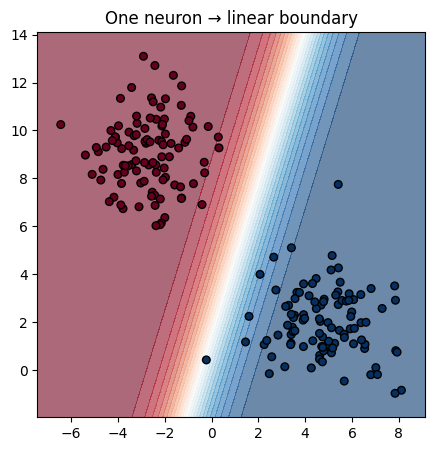

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Equivalent: one neuron for linearly separable data
X, y = make_blobs(n_samples=200, centers=2, random_state=42, cluster_std=1.5)
X_t = torch.FloatTensor(X)
y_t = torch.FloatTensor(y).unsqueeze(1)

model = nn.Sequential(nn.Linear(2, 1), nn.Sigmoid())
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
criterion = nn.BCELoss()

for _ in range(200):
    optimizer.zero_grad()
    criterion(model(X_t), y_t).backward()
    optimizer.step()

# Plot decision boundary
xx, yy = np.meshgrid(np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 200),
                     np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 200))
grid = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])
with torch.no_grad():
    Z = model(grid).reshape(xx.shape).numpy()

plt.figure(figsize=(5, 5))
plt.contourf(xx, yy, Z, levels=25, cmap="RdBu", alpha=0.6)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="RdBu", edgecolors="k", s=30)
plt.title("One neuron → linear boundary")
plt.show()

## Experiment 2: non-linear data requires hidden layers

**Setup in Playground:**
1. Select the **circle** dataset.
2. Start with no hidden layers and press Play. Observe that a single neuron **fails**.
3. Add a hidden layer with **4 neurons** (ReLU or Tanh activation).
4. Reset and press Play again.

**What you should see:** with the hidden layer, the boundary curves around the inner circle. Without it, the model is stuck drawing a straight line.

**Key insight:** hidden layers + activation functions enable non-linear decision boundaries.

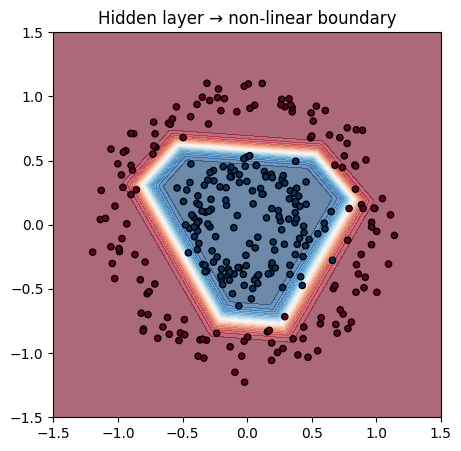

In [ ]:
from sklearn.datasets import make_circles

X_c, y_c = make_circles(n_samples=300, noise=0.1, factor=0.4, random_state=42)
X_ct = torch.FloatTensor(X_c)
y_ct = torch.FloatTensor(y_c).unsqueeze(1)

# Model with hidden layer
model = nn.Sequential(
    nn.Linear(2, 4), nn.ReLU(),
    nn.Linear(4, 1), nn.Sigmoid(),
)
optimizer = torch.optim.Adam(model.parameters(), lr=0.05)
criterion = nn.BCELoss()

for _ in range(500):
    optimizer.zero_grad()
    criterion(model(X_ct), y_ct).backward()
    optimizer.step()

xx, yy = np.meshgrid(np.linspace(-1.5, 1.5, 200), np.linspace(-1.5, 1.5, 200))
grid = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])
with torch.no_grad():
    Z = model(grid).reshape(xx.shape).numpy()

plt.figure(figsize=(5, 5))
plt.contourf(xx, yy, Z, levels=25, cmap="RdBu", alpha=0.6)
plt.scatter(X_c[:, 0], X_c[:, 1], c=y_c, cmap="RdBu", edgecolors="k", s=20)
plt.title("Hidden layer → non-linear boundary")
plt.show()

## Experiment 3: activation functions

**Setup in Playground:**
1. Use the **XOR** dataset with 1 hidden layer (4 neurons).
2. Try each activation: **ReLU**, **Tanh**, **Sigmoid**, **Linear**.
3. Compare convergence speed and final boundary shape.

**Expected results:**
- **ReLU / Tanh**: converge relatively fast, good non-linear boundary.
- **Sigmoid**: can be slower due to saturation (gradients shrink for extreme inputs).
- **Linear**: **fails** — linear(linear) = linear, no non-linearity is introduced.

**Key insight:** the activation function is what breaks linearity. Without it, adding layers does nothing useful.

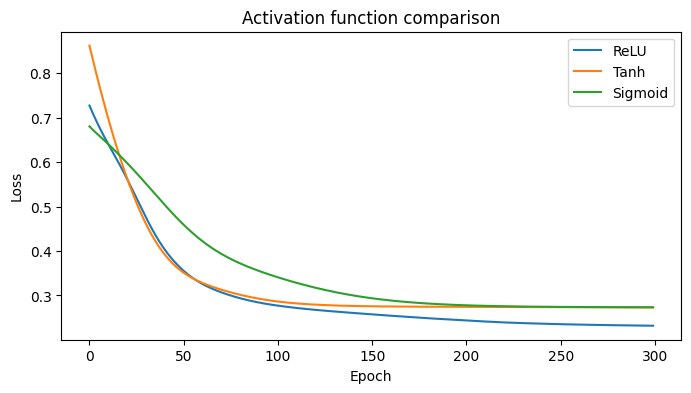

In [ ]:
# Compare activations on XOR
from sklearn.datasets import make_moons

X_m, y_m = make_moons(n_samples=300, noise=0.15, random_state=42)
X_mt = torch.FloatTensor(X_m)
y_mt = torch.FloatTensor(y_m).unsqueeze(1)

activations = {"ReLU": nn.ReLU(), "Tanh": nn.Tanh(), "Sigmoid": nn.Sigmoid()}
histories = {}

for name, act in activations.items():
    model = nn.Sequential(nn.Linear(2, 8), act, nn.Linear(8, 1))
    opt = torch.optim.Adam(model.parameters(), lr=0.01)
    crit = nn.BCEWithLogitsLoss()
    losses = []
    for _ in range(300):
        opt.zero_grad()
        loss = crit(model(X_mt), y_mt)
        loss.backward()
        opt.step()
        losses.append(loss.item())
    histories[name] = losses

plt.figure(figsize=(8, 4))
for name, losses in histories.items():
    plt.plot(losses, label=name)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Activation function comparison")
plt.legend()
plt.show()

## Experiment 4: feature engineering

**Setup in Playground:**
1. Select the **XOR** dataset.
2. Enable the **x₁ × x₂** feature. Remove all hidden layers.
3. Press Play.

**What you should see:** XOR is solved with just one neuron! The multiplication feature transforms the problem into something linearly separable.

**Key insight:** sometimes a well-chosen input feature can replace an entire hidden layer. In deep learning, the network *learns* these transformations automatically — but sometimes adding domain-specific features helps.

See ➜ [complementary/xor_linearity.ipynb](xor_linearity.ipynb) for a detailed exploration.

## Experiment 5: learning rate

**Setup in Playground:**
1. Use the **circle** dataset with 1 hidden layer (4 neurons, Tanh).
2. Try learning rates: **0.001**, **0.03**, **1.0**.
3. Observe training speed and stability.

| LR | Effect |
|----|--------|
| **0.001** | Very slow convergence — loss barely moves |
| **0.03** | Stable, steady convergence |
| **1.0** | Loss oscillates wildly or diverges |

**Key insight:** the learning rate is the most important hyperparameter to tune. Too high → unstable. Too low → wastes time.

## Experiment 6: overfitting and regularization

**Setup in Playground:**
1. Select the **spiral** dataset with **high noise**.
2. Use a large network: 2 hidden layers, 8 neurons each, ReLU.
3. Train without regularization — observe the wiggly boundary.
4. Now apply **L2 regularization** (strength ~0.1) — the boundary smooths out.

**What's happening:** without regularization, the model fits every noisy point. L2 penalizes large weights, forcing simpler (smoother) boundaries.

See ➜ [04_training_dynamics.ipynb](../04_training_dynamics.ipynb) for a deeper dive into regularization.

## Challenge: solve the spiral

**Task:** configure a network in TensorFlow Playground that cleanly separates the **spiral** dataset.

**Hints:**
1. You'll likely need **2–3 hidden layers** with **6–8 neurons** each.
2. **ReLU** tends to work well here.
3. A moderate learning rate (0.01–0.03) is a good starting point.
4. If the boundary is too wiggly, add some L2 regularization.

**Reflect:** what was the simplest architecture that worked? How did the learning rate and regularization affect the result?

## Summary

| Concept | Playground experiment | Takeaway |
|---------|----------------------|----------|
| Linear classifier | One neuron, two clusters | A single neuron draws a straight line |
| Non-linearity | Circle dataset + hidden layer | Hidden layers enable curved boundaries |
| Activation functions | XOR + different activations | Non-linear activation is essential |
| Feature engineering | XOR + x₁×x₂ feature | Good features can replace model complexity |
| Learning rate | Circle + varying LR | Most important hyperparameter |
| Regularization | Spiral + L2 | Prevents overfitting, smooths boundaries |

All of these concepts translate directly to real PyTorch models — the Playground just makes them visible.